In [1]:
import pandas as pd

# Load ETH CSV
eth_df = pd.read_csv(r'feature_datasets\ETH_features.csv', parse_dates=True, index_col=0)

# Define X and y
eth_y = eth_df['Close'].shift(-1)          # next-day close price
eth_X = eth_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
eth_X = eth_X.iloc[:-1]
eth_y = eth_y.iloc[:-1]

# Optional: check shapes
print("ETH X shape:", eth_X.shape)
print("ETH y shape:", eth_y.shape)

ETH X shape: (915, 29)
ETH y shape: (915,)


## Basic 70-30 split

In [2]:
# 70% train / 30% test split (time-based)
split_idx = int(len(eth_X) * 0.7)

eth_X_train = eth_X.iloc[:split_idx].values
eth_X_test  = eth_X.iloc[split_idx:].values

eth_y_train = eth_y.iloc[:split_idx].values
eth_y_test  = eth_y.iloc[split_idx:].values

print("ETH X_train shape:", eth_X_train.shape)
print("ETH X_test shape:", eth_X_test.shape)
print("ETH y_train shape:", eth_y_train.shape)
print("ETH y_test shape:", eth_y_test.shape)

ETH X_train shape: (640, 29)
ETH X_test shape: (275, 29)
ETH y_train shape: (640,)
ETH y_test shape: (275,)


In [3]:
eth_test_dates = eth_df.index[-len(eth_X_test):]  

In [4]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
eth_X_train_scaled = scaler.fit_transform(eth_X_train)

# Transform TEST using the same scaler
eth_X_test_scaled = scaler.transform(eth_X_test)

# Check shapes
print("Scaled X_train shape:", eth_X_train_scaled.shape)
print("Scaled X_test shape:", eth_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [5]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
eth_y_train_scaled = y_scaler.fit_transform(eth_y_train.reshape(-1,1)).flatten()

# Scale test target
eth_y_test_scaled = y_scaler.transform(eth_y_test.reshape(-1,1)).flatten()

In [6]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for ETH using scaled target
eth_X_train_seq, eth_y_train_seq = create_sequences(eth_X_train_scaled, eth_y_train_scaled, time_steps=30)
eth_X_test_seq, eth_y_test_seq = create_sequences(eth_X_test_scaled, eth_y_test_scaled, time_steps=30)

# Check shapes
print("ETH X_train_seq shape:", eth_X_train_seq.shape)
print("ETH y_train_seq shape:", eth_y_train_seq.shape)
print("ETH X_test_seq shape:", eth_X_test_seq.shape)
print("ETH y_test_seq shape:", eth_y_test_seq.shape)

ETH X_train_seq shape: (610, 30, 29)
ETH y_train_seq shape: (610,)
ETH X_test_seq shape: (245, 30, 29)
ETH y_test_seq shape: (245,)


### Train Bi_LSTM

In [7]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [8]:
# Get number of features from the sequences
input_size = eth_X_train_seq.shape[2]

# Initialize Bi-LSTM model
model = BiLSTM(input_size=input_size)

In [9]:
model = train_model(model, eth_X_train_seq, eth_y_train_seq, epochs=50,batch_size=32, lr=0.001
)

Epoch [10/50], Loss: 0.002921
Epoch [20/50], Loss: 0.001900
Epoch [30/50], Loss: 0.001889
Epoch [40/50], Loss: 0.003203
Epoch [50/50], Loss: 0.007049


In [10]:
eth_preds = predict_model(model, eth_X_test_seq)

# check
print("Predictions shape:", eth_preds.shape)
print("First 10 predictions:", eth_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.21785723]
 [0.20872043]
 [0.20972024]
 [0.21062197]
 [0.2080203 ]
 [0.20829257]
 [0.20161341]
 [0.19642943]
 [0.18981789]
 [0.18837881]]


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
eth_preds_actual = y_scaler.inverse_transform(eth_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
eth_y_test_actual = eth_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(eth_y_test_actual, eth_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(eth_y_test_actual, eth_preds_actual)
r2 = r2_score(eth_y_test_actual, eth_preds_actual)
mape = np.mean(np.abs((eth_y_test_actual - eth_preds_actual) / eth_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 13718.44
RMSE: 117.13
MAE: 88.68
R2 Score: 0.6736
MAPE: 4.51%


In [12]:
eth_preds_actual = y_scaler.inverse_transform(eth_preds.reshape(-1,1))

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = eth_df.index[-len(eth_X_test):][30:]  # test dates aligned with sequences
actual_seq = eth_y_test[30:]                      # actual prices aligned
pred_seq = eth_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot

,Actual,Predicted
Date,,
2023-05-02,1870.789307,1825.513794
2023-05-03,1904.651855,1790.625488
2023-05-04,1877.704102,1794.443115
2023-05-05,1995.060913,1797.886353
2023-05-06,1900.221802,1787.952026
...,...,...
2023-12-28,2347.566162,2045.464478
2023-12-29,2300.690674,2093.378418
2023-12-30,2292.065430,2124.737305


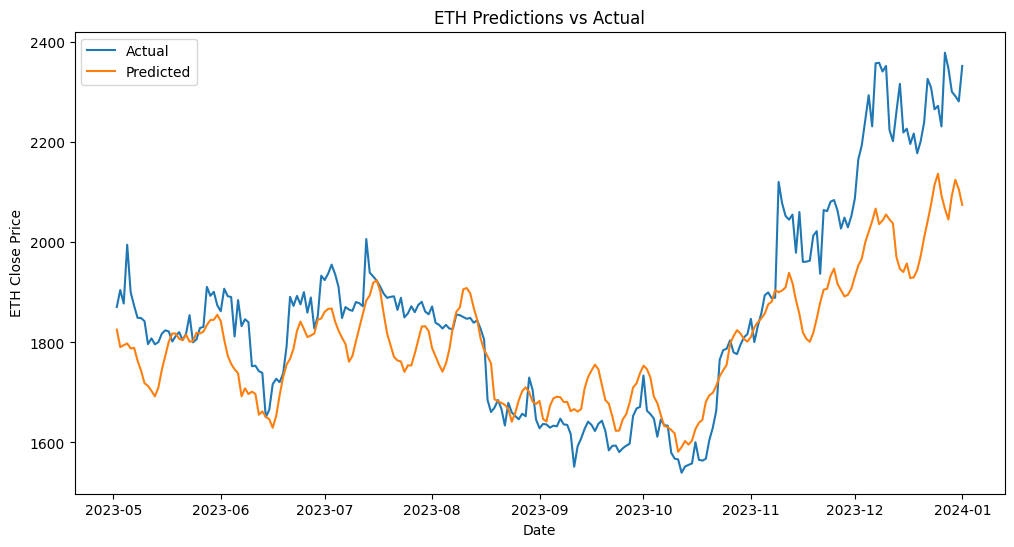

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("ETH Close Price")
plt.title("ETH Predictions vs Actual")
plt.legend()
plt.show()

## Each year 70% train split

In [15]:
# Get unique years from your DataFrame index
years = eth_df.index.year.unique()
print("Years in dataset:", years)

Years in dataset: Index([2021, 2022, 2023, 2024], dtype='int32', name='Date')


In [16]:
X_train_list = []
y_train_list = []

In [17]:
for year in years:
    # Filter data for this year
    eth_year = eth_df[eth_df.index.year == year]

    # Calculate split index for 70%
    split_idx = int(len(eth_year) * 0.7)

    # Take first 70% as training
    X_train_year = eth_year.iloc[:split_idx, 1:].values  # all features except target column
    y_train_year = eth_year.iloc[:split_idx, 0].values   # target column (e.g., next-day Close)

    # Append to lists
    X_train_list.append(X_train_year)
    y_train_list.append(y_train_year)

    print(f"Year {year}: {len(X_train_year)} train samples")

Year 2021: 129 train samples
Year 2022: 255 train samples
Year 2023: 255 train samples
Year 2024: 0 train samples


In [18]:
import numpy as np

# Stack all years’ train sets
X_train_combined = np.vstack(X_train_list)
y_train_combined = np.hstack(y_train_list)

print("Combined X_train shape:", X_train_combined.shape)
print("Combined y_train shape:", y_train_combined.shape)

Combined X_train shape: (639, 29)
Combined y_train shape: (639,)


In [19]:
X_test_list = []
y_test_list = []

In [20]:
for year in years:
    eth_year = eth_df[eth_df.index.year == year]

    # Calculate split index (same as for train)
    split_idx = max(1, int(len(eth_year) * 0.7))  # ensures at least 1 sample in train

    # Take the remaining 30% as test
    X_test_year = eth_year.iloc[split_idx:, 1:].values   # features
    y_test_year = eth_year.iloc[split_idx:, 0].values    # target

    # Append to test lists
    X_test_list.append(X_test_year)
    y_test_list.append(y_test_year)

    print(f"Year {year}: {len(X_test_year)} test samples")


Year 2021: 56 test samples
Year 2022: 110 test samples
Year 2023: 110 test samples
Year 2024: 0 test samples


In [21]:
import numpy as np

X_test_combined = np.vstack(X_test_list)
y_test_combined = np.hstack(y_test_list)

print("Combined X_test shape:", X_test_combined.shape)
print("Combined y_test shape:", y_test_combined.shape)

Combined X_test shape: (276, 29)
Combined y_test shape: (276,)


In [22]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale training data
X_train_scaled = x_scaler.fit_transform(X_train_combined)
y_train_scaled = y_scaler.fit_transform(y_train_combined.reshape(-1,1)).flatten()

In [23]:
X_test_scaled = x_scaler.transform(X_test_combined)
y_test_scaled = y_scaler.transform(y_test_combined.reshape(-1,1)).flatten()

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)
print("Scaled y_train shape:", y_train_scaled.shape)
print("Scaled y_test shape:", y_test_scaled.shape)

Scaled X_train shape: (639, 29)
Scaled X_test shape: (276, 29)
Scaled y_train shape: (639,)
Scaled y_test shape: (276,)


In [24]:
import numpy as np

def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for train and test
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)

# Check shapes
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (609, 30, 29)
y_train_seq shape: (609,)
X_test_seq shape: (246, 30, 29)
y_test_seq shape: (246,)


### training

In [25]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [26]:
# Get number of features from the sequences
input_size = X_train_seq.shape[2]   # use the combined train sequences

# Initialize Bi-LSTM model
model_y = BiLSTM(input_size=input_size)

In [27]:
model_y = train_model(model_y, X_train_seq, y_train_seq, epochs=50, batch_size=32, lr=0.001)

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/50], Loss: 0.005852
Epoch [20/50], Loss: 0.006710
Epoch [30/50], Loss: 0.003159
Epoch [40/50], Loss: 0.000997
Epoch [50/50], Loss: 0.000822


In [28]:
eth_preds_ev_year =predict_model(model_y, X_test_seq)
eth_preds_ev_year[:10]

array([[0.83140767],
       [0.8385291 ],
       [0.8560222 ],
       [0.8640546 ],
       [0.8527709 ],
       [0.8205459 ],
       [0.8126075 ],
       [0.82049614],
       [0.79360414],
       [0.7716996 ]], dtype=float32)

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the trained model
eth_preds_ev_year = predict_model(model_y, X_test_seq)

# Inverse scale predictions to original price values
eth_preds_actual = y_scaler.inverse_transform(eth_preds_ev_year.reshape(-1,1))

# Inverse scale the test targets
eth_y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

# Calculate metrics
mse = mean_squared_error(eth_y_test_actual, eth_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(eth_y_test_actual, eth_preds_actual)
r2 = r2_score(eth_y_test_actual, eth_preds_actual)
mape = np.mean(np.abs((eth_y_test_actual - eth_preds_actual) / eth_y_test_actual)) * 100

# Print results
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 28824.05
RMSE: 169.78
MAE: 85.24
R2 Score: 0.9562
MAPE: 4.89%


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Actual and predicted prices
actual_test_seq = y_scaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()
predicted_test_seq = eth_preds_actual.flatten()

# Create DataFrame for plotting (no Date index)
df_eth_plot_year = pd.DataFrame({
    "Actual": actual_test_seq,
    "Predicted": predicted_test_seq
})

# Display first few rows
df_eth_plot_year.head()

,Actual,Predicted
0,4358.737305,3997.975830
1,4315.061523,4023.709473
2,4439.357910,4086.921631
3,4119.815918,4115.947266
4,3908.496094,4075.173096


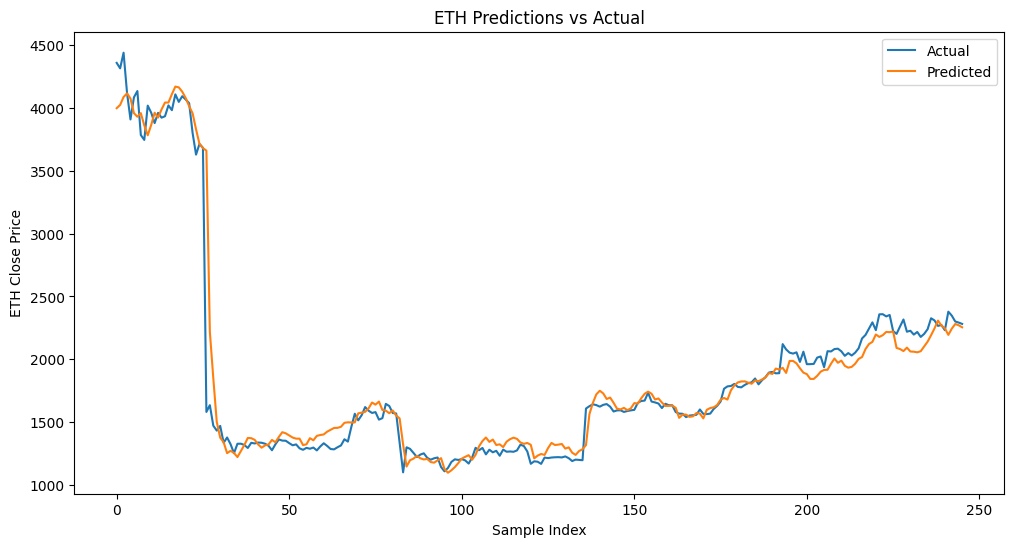

In [31]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(df_eth_plot_year["Actual"], label="Actual")
plt.plot(df_eth_plot_year["Predicted"], label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("ETH Close Price")
plt.title("ETH Predictions vs Actual")
plt.legend()
plt.show()

## Three-quaters train

In [32]:
# 75% train / 25% test split (time-based)
q3_split_idx = int(len(eth_X) * 0.75)

eth_q3_X_train = eth_X.iloc[:q3_split_idx].values
eth_q3_X_test  = eth_X.iloc[q3_split_idx:].values

eth_q3_y_train = eth_y.iloc[:q3_split_idx].values
eth_q3_y_test  = eth_y.iloc[q3_split_idx:].values

# Shape checks
print("Q3 ETH X_train shape:", eth_q3_X_train.shape)
print("Q3 ETH X_test shape:", eth_q3_X_test.shape)
print("Q3 ETH y_train shape:", eth_q3_y_train.shape)
print("Q3 ETH y_test shape:", eth_q3_y_test.shape)

Q3 ETH X_train shape: (686, 29)
Q3 ETH X_test shape: (229, 29)
Q3 ETH y_train shape: (686,)
Q3 ETH y_test shape: (229,)


In [33]:
# Assuming btc_df has Date as index
eth_q3_test_dates = eth_df.index[-len(eth_q3_X_test):]

print("Q3 test dates length:", len(eth_q3_test_dates))

Q3 test dates length: 229


In [34]:
from sklearn.preprocessing import MinMaxScaler

# Feature scaler
eth_q3_X_scaler = MinMaxScaler()

# Fit on TRAIN only
eth_q3_X_train_scaled = eth_q3_X_scaler.fit_transform(eth_q3_X_train)

# Transform TEST using same scaler
eth_q3_X_test_scaled = eth_q3_X_scaler.transform(eth_q3_X_test)

print("Q3 Scaled X_train shape:", eth_q3_X_train_scaled.shape)
print("Q3 Scaled X_test shape:", eth_q3_X_test_scaled.shape)


Q3 Scaled X_train shape: (686, 29)
Q3 Scaled X_test shape: (229, 29)


In [35]:
# Target scaler
eth_q3_y_scaler = MinMaxScaler()

# Scale training target
eth_q3_y_train_scaled = eth_q3_y_scaler.fit_transform(
    eth_q3_y_train.reshape(-1, 1)
).flatten()

# Scale test target
eth_q3_y_test_scaled = eth_q3_y_scaler.transform(
    eth_q3_y_test.reshape(-1, 1)
).flatten()
14
print("Q3 Scaled y_train shape:", eth_q3_y_train_scaled.shape)
print("Q3 Scaled y_test shape:", eth_q3_y_test_scaled.shape)

Q3 Scaled y_train shape: (686,)
Q3 Scaled y_test shape: (229,)


In [36]:
import numpy as np

def create_sequences_q3(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

In [37]:
# Create sequences (30-day window)
eth_q3_X_train_seq, eth_q3_y_train_seq = create_sequences_q3(
    eth_q3_X_train_scaled,
    eth_q3_y_train_scaled,
    time_steps=30
)

eth_q3_X_test_seq, eth_q3_y_test_seq = create_sequences_q3(
    eth_q3_X_test_scaled,
    eth_q3_y_test_scaled,
    time_steps=30
)

# Final shape checks
print("Q3 X_train_seq shape:", eth_q3_X_train_seq.shape)
print("Q3 y_train_seq shape:", eth_q3_y_train_seq.shape)
print("Q3 X_test_seq shape:", eth_q3_X_test_seq.shape)
print("Q3 y_test_seq shape:", eth_q3_y_test_seq.shape)

Q3 X_train_seq shape: (656, 30, 29)
Q3 y_train_seq shape: (656,)
Q3 X_test_seq shape: (199, 30, 29)
Q3 y_test_seq shape: (199,)


### Model training

In [38]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [39]:
# Get number of features
eth_q3_input_size = eth_q3_X_train_seq.shape[2]

# Initialize model
eth_q3_model = BiLSTM(input_size=eth_q3_input_size)

In [40]:
# Train model
eth_q3_model = train_model(eth_q3_model, eth_q3_X_train_seq, eth_q3_y_train_seq, epochs=50, batch_size=32, lr=0.001)

Epoch [10/50], Loss: 0.002834
Epoch [20/50], Loss: 0.002081
Epoch [30/50], Loss: 0.004913
Epoch [40/50], Loss: 0.001418
Epoch [50/50], Loss: 0.001143


In [41]:
# Generate predictions
eth_q3_preds = predict_model(eth_q3_model, eth_q3_X_test_seq)

print("Q3 Predictions shape:", eth_q3_preds.shape)
print("First 10 Q3 predictions:", eth_q3_preds[:10])

Q3 Predictions shape: (199, 1)
First 10 Q3 predictions: [[0.19179475]
 [0.20428045]
 [0.21638158]
 [0.22698817]
 [0.23293157]
 [0.24027738]
 [0.25452852]
 [0.2610463 ]
 [0.25500774]
 [0.25299752]]


In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the Q3 trained model
eth_q3_preds_eval = predict_model(eth_q3_model, eth_q3_X_test_seq)

# Inverse scale predictions to original price values
eth_q3_preds_actual = eth_q3_y_scaler.inverse_transform(
    eth_q3_preds_eval.reshape(-1, 1)
)

# Inverse scale the test targets
eth_q3_y_test_actual = eth_q3_y_scaler.inverse_transform(
    eth_q3_y_test_seq.reshape(-1, 1)
)

# Calculate metrics
eth_q3_mse = mean_squared_error(eth_q3_y_test_actual, eth_q3_preds_actual)
eth_q3_rmse = np.sqrt(eth_q3_mse)
eth_q3_mae = mean_absolute_error(eth_q3_y_test_actual, eth_q3_preds_actual)
eth_q3_r2 = r2_score(eth_q3_y_test_actual, eth_q3_preds_actual)
eth_q3_mape = np.mean(np.abs((eth_q3_y_test_actual - eth_q3_preds_actual) / eth_q3_y_test_actual)) * 100

# Print results
print(f"Q3 MSE: {eth_q3_mse:.2f}")
print(f"Q3 RMSE: {eth_q3_rmse:.2f}")
print(f"Q3 MAE: {eth_q3_mae:.2f}")
print(f"Q3 R2 Score: {eth_q3_r2:.4f}")
print(f"Q3 MAPE: {eth_q3_mape:.2f}%")

Q3 MSE: 13859.68
Q3 RMSE: 117.73
Q3 MAE: 100.78
Q3 R2 Score: 0.7259
Q3 MAPE: 5.65%


In [43]:
# Inverse scale predictions
eth_q3_preds_actual = eth_q3_y_scaler.inverse_transform(
    eth_q3_preds.reshape(-1, 1)
)

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Align dates and values
eth_q3_dates_seq = eth_df.index[-len(eth_q3_X_test):][30:]
eth_q3_actual_seq = eth_q3_y_test[30:]
eth_q3_pred_seq = eth_q3_preds_actual.flatten()

# Create DataFrame
eth_q3_df_plot = pd.DataFrame({
    "Date": eth_q3_dates_seq,
    "Actual": eth_q3_actual_seq,
    "Predicted": eth_q3_pred_seq
})

eth_q3_df_plot.set_index("Date", inplace=True)
eth_q3_df_plot.head(10)


,Actual,Predicted
Date,,
2023-06-17,1727.204102,1725.995483
2023-06-18,1720.577515,1773.671631
2023-06-19,1737.659424,1819.879150
2023-06-20,1792.119995,1860.379883
2023-06-21,1891.007202,1883.074463
2023-06-22,1872.942993,1911.124146
2023-06-23,1892.862061,1965.541382
2023-06-24,1876.059692,1990.429077
2023-06-25,1900.506104,1967.371216


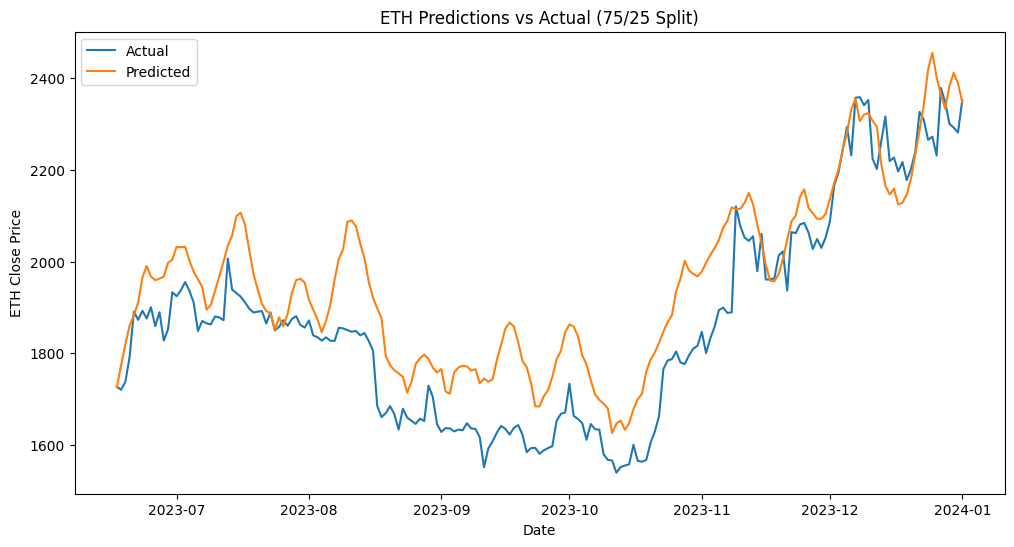

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(eth_q3_df_plot["Actual"], label="Actual")
plt.plot(eth_q3_df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("ETH Close Price")
plt.title("ETH Predictions vs Actual (75/25 Split)")
plt.legend()
plt.show()

## Saving the best model (out of accuracy) for Ethereum

In [46]:
# import joblib
# joblib.dump(model_y, "Ethereum_base_model.pkl")

# Finetuning

In [47]:
import optuna

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
